In [7]:
!pip install kagglehub --upgrade

In [8]:
import kagglehub

In [9]:
# download the dataset from kaggle

kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

Using Colab cache for faster access to the 'million-song-dataset-spotify-lastfm' dataset.


'/kaggle/input/million-song-dataset-spotify-lastfm'

In [10]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data_path = Path("/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1")
songs_data_path = data_path / 'Music Info.csv'
users_data_path = data_path / 'User Listening History.csv'

Songs Dataset

In [12]:
# load the songs data
df_songs = pd.read_csv(songs_data_path)
df_songs.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [13]:
# size of dataset
df_songs.shape

(50683, 21)

In [14]:
# data info
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  object 
 1   name                 50683 non-null  object 
 2   artist               50683 non-null  object 
 3   spotify_preview_url  50683 non-null  object 
 4   spotify_id           50683 non-null  object 
 5   tags                 49556 non-null  object 
 6   genre                22348 non-null  object 
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null 

In [15]:
# drop columns from data
columns_to_drop = ["spotify_preview_url"]
df_songs.drop(columns=columns_to_drop,inplace=True)
df_songs.head()

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


Missing Values

In [16]:
# missing values
df_songs.isna().sum()

,0
track_id,0
name,0
artist,0
spotify_id,0
tags,1127
genre,28335
year,0
duration_ms,0
danceability,0
energy,0


In [17]:
import missingno as msno

<Axes: >

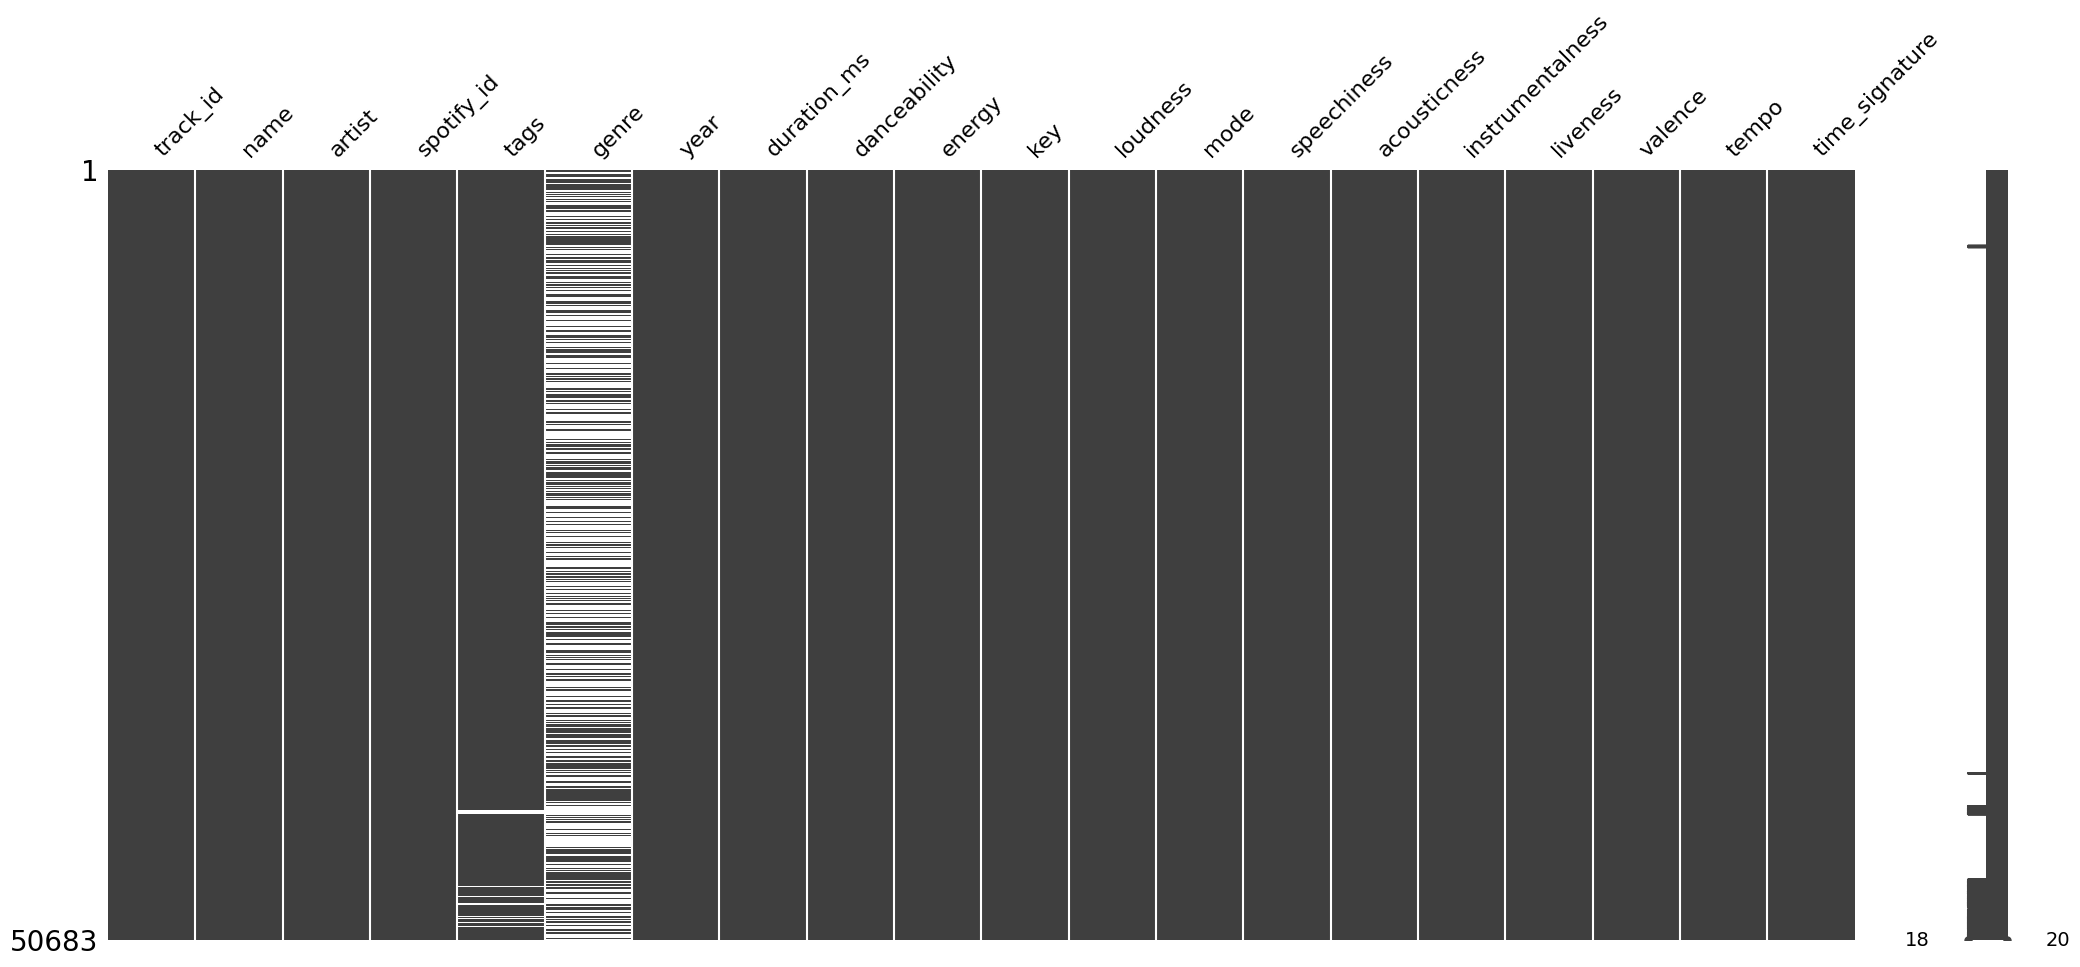

In [18]:
msno.matrix(df_songs)

In [19]:
# ratio of missing values in data
(
    df_songs
    .isna()
    .mean()
    .sort_values(ascending=False)
    .head(2)
    .mul(100)
)

,0
genre,55.906320
tags,2.223625


Duplicates in Data

In [20]:
# check for duplicates based on name of the song
(
    df_songs
    .assign(name=df_songs['name'].str.lower())
    .duplicated(subset='name')
    .sum()
)

np.int64(815)

There are 815 duplicate rows based on the name of the song

In [21]:
# rows that are duplicate
(
    df_songs
    .loc[
        df_songs
        .assign(name=df_songs['name'].str.lower())
        .duplicated(subset='name',keep=False)
    ]
    .assign(name=df_songs['name'].str.lower())
    .sort_values("name")
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
34480,TRKKZMK128F4257579,3 am,Liv Kristine,1TgsnkiolcBhQssCR37JXx,"female_vocalists, power_metal, gothic_metal, g...",NaN,2005,302880,0.516,0.840,0,-6.038,0,0.0390,0.152000,0.005970,0.107,0.441,78.009,4
6588,TRGGALK12903CB68E5,3 am,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, pop, alternative_rock, 90s,...",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.005730,0.000000,0.120,0.543,108.031,4
29795,TRLOXMF128F934BF04,3am,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, 90s, piano, american, pop_rock",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.005730,0.000000,0.120,0.543,108.031,4
43800,TRPWOAS128E0781045,3am,Halsey,1OfLNb6dQ9dra1B58iT9Ex,pop_rock,NaN,2020,234858,0.385,0.871,0,-4.604,0,0.0795,0.009060,0.000000,0.579,0.538,189.760,4
15088,TRJRBRX128F4255789,4th of july,Soundgarden,237oH9rNUYpIBeHfAn3WJ0,"hard_rock, 90s, grunge",NaN,1994,308866,0.368,0.749,5,-5.523,0,0.0392,0.109000,0.000372,0.175,0.193,141.901,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34772,TRJFGYO128F4259743,you're the one that i want,Lo-Fang,1dEHQktvcM8vCCyI1x7yVB,"indie, male_vocalists, cover",NaN,2014,204706,0.445,0.309,11,-12.517,0,0.0404,0.643000,0.000369,0.224,0.153,119.754,4
32677,TRFZYLL128F146902A,you've really got a hold on me,Smokey Robinson and The Miracles,03AkIZeRvGpTvDF9vNJtdj,"soul, 60s, oldies",Rock,2012,179513,0.674,0.515,0,-6.895,1,0.0296,0.724000,0.000000,0.339,0.596,116.678,3
20976,TRUXHGS128F145E41A,you've really got a hold on me,The Miracles,01FtGX94CSvO5Zxs5B6AMM,"soul, 60s, oldies",NaN,1994,180266,0.679,0.406,0,-10.533,1,0.0312,0.755000,0.000000,0.412,0.511,117.940,3
27680,TRXWPMW12903CB42A0,zombies,Childish Gambino,73kAUSAht4YOR7xNPmNb2L,funk,NaN,2016,281813,0.653,0.411,0,-11.986,1,0.1270,0.503000,0.000969,0.067,0.468,160.055,4


In [22]:
# duplicates in the data based on spotify_id
(
    df_songs
    .duplicated(subset="spotify_id")
    .sum()
)

np.int64(9)

In [23]:
# duplicate songs in the data
(
    df_songs
    .duplicated(subset=["spotify_id","year","duration_ms"])
    .sum()
)

np.int64(9)

9 Duplicate songs in the data

In [24]:
# rows that have duplicate data
(
    df_songs
    .loc[
        df_songs
        .duplicated(subset=["spotify_id","year","duration_ms"],keep=False)
    ]
    .sort_values(["spotify_id","year","duration_ms"])
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
15326,TRJNHPN128F92EF139,Adagio For Strings,Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,"instrumental, classical, soundtrack, beautiful",NaN,2014,431412,0.140,0.0947,10,-18.599,0,0.0458,0.97800,0.478000,0.0735,0.0365,84.560,4
21570,TRLSRQD128F426CFF8,"Adagio for Strings, Op. 11",Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,classical,NaN,2014,431412,0.140,0.0947,10,-18.599,0,0.0458,0.97800,0.478000,0.0735,0.0365,84.560,4
14861,TRLOZQZ128F92E8A3F,How Do You Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,"rap, hip_hop",NaN,2011,289000,0.832,0.7850,8,-2.859,1,0.0930,0.11100,0.000007,0.0623,0.8120,92.468,4
14981,TRXHJQY128F42B5094,How Do U Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,"rap, hip_hop, american",Rap,2011,289000,0.832,0.7850,8,-2.859,1,0.0930,0.11100,0.000007,0.0623,0.8120,92.468,4
37040,TRGCZFO128F92EE221,Je pense à toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,"alternative, beautiful, french",NaN,2005,316880,0.680,0.3990,11,-11.585,0,0.0279,0.74900,0.001610,0.1580,0.8280,106.349,4
49162,TRZBNQU128F148C04F,Je Pense A Toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,NaN,NaN,2005,316880,0.680,0.3990,11,-11.585,0,0.0279,0.74900,0.001610,0.1580,0.8280,106.349,4
13427,TRJQFIT128E0781CED,Too Much Too Young,The Specials,0ndKJL8gA4zLl317M7vndn,"punk, 80s, new_wave, reggae, ska",NaN,2012,116160,0.597,0.8390,2,-9.052,1,0.0471,0.44700,0.000134,0.3100,0.9650,156.058,4
46512,TRDTUTO128F422F138,Too Much Too Young (Live),The Specials,0ndKJL8gA4zLl317M7vndn,ska,NaN,2012,116160,0.597,0.8390,2,-9.052,1,0.0471,0.44700,0.000134,0.3100,0.9650,156.058,4
1684,TRRZUGN128F42A1EEE,There There,Radiohead,0thdzbW0cRKCx12VbBRB6T,"rock, electronic, alternative, indie, alternat...",Rock,2008,323600,0.614,0.6770,9,-8.317,0,0.0323,0.01930,0.518000,0.1080,0.7170,126.477,4
2983,TRXFHCL128F92E0989,"There, There",Radiohead,0thdzbW0cRKCx12VbBRB6T,"rock, electronic, alternative, indie, alternat...",NaN,2008,323600,0.614,0.6770,9,-8.317,0,0.0323,0.01930,0.518000,0.1080,0.7170,126.477,4


In [25]:
# drop duplicates
df_songs.drop_duplicates(subset=["spotify_id","year","duration_ms"],inplace=True)

In [26]:
# check for duplicates
(
    df_songs
    .duplicated(subset=["spotify_id","year","duration_ms"])
    .sum()
)

np.int64(0)

Duplicate songs have been removed from the data

Column Wise Analysis

**Categorical Columns**

In [28]:
# list of columns in data
df_songs.columns

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre', 'year',
       'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='object')

In [29]:
df_songs.dtypes

,0
track_id,object
name,object
artist,object
spotify_id,object
tags,object
genre,object
year,int64
duration_ms,int64
danceability,float64
energy,float64


In [30]:
# shape of data
df_songs.shape

(50674, 20)

In [31]:
# Categorical Columns
categorical_features = df_songs.select_dtypes(include="object").columns
categorical_features

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre'], dtype='object')

In [32]:
def categorical_analysis(df,feature_names,k_artists=15):
    for feature in feature_names:
        print(f"Number of categories in column {feature} are ",df[feature].str.lower().nunique())

        if feature in ["artist","genre"]:
            print(df[feature].value_counts().head(k_artists))

        if feature == "genre":
            print(f"The unique categories in {feature} column are: ", df[feature].dropna().unique())
        print("#" * 75)

In [33]:
# perform catagorical analysis
categorical_analysis(df_songs,categorical_features)

Number of categories in column track_id are  50674
###########################################################################
Number of categories in column name are  49860
###########################################################################
Number of categories in column artist are  8317
artist
The Rolling Stones    132
Radiohead             110
Autechre              105
Tom Waits             100
Bob Dylan              98
The Cure               94
Metallica              85
Johnny Cash            84
Nine Inch Nails        83
Sonic Youth            81
Iron Maiden            76
In Flames              76
Elliott Smith          76
Mogwai                 75
Boards of Canada       75
Name: count, dtype: int64
###########################################################################
Number of categories in column spotify_id are  50674
###########################################################################
Number of categories in column tags are  20054
###########################

**Observations**:  
1. The `Track ID` and `Spotify ID`'s are unique for every row.
2. The song names have some repititions. That is because there are a few songs in the data whose name is the same but is sung by a different artist.
3. The dataset contains songs of about `8317 artists`.
4. There are 15 distinct categories in the `Genre` column.

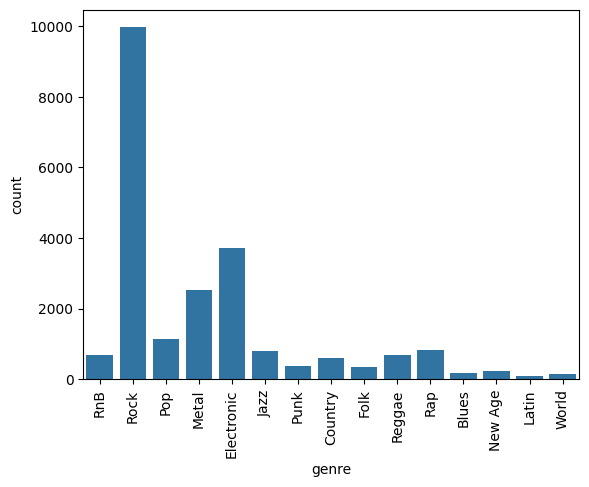

In [34]:
# countplot of genre
sns.countplot(df_songs,x="genre")
plt.xticks(rotation=90)
plt.show()

In [35]:
# genre group
genre_group = df_songs.groupby("genre")
genre_group[['genre','tags']].sample(3)

,genre,tags
23809,Blues,blues
20359,Blues,"hardcore, metalcore, post_hardcore"
24003,Blues,"jazz, soul, blues, oldies"
39289,Country,"electronic, idm"
33348,Country,country
33019,Country,country
47730,Electronic,"industrial, gothic"
26286,Electronic,"electronic, chillout, post_rock, trip_hop, lounge"
39212,Electronic,"downtempo, idm"
45783,Folk,new_age


In [36]:
df_songs['tags'][0]

'rock, alternative, indie, alternative_rock, indie_rock, 00s'

In [37]:
all_tags = []
for tags in df_songs["tags"].dropna().str.replace(" ","").str.split(","):
    all_tags.extend(tags)

In [38]:
print("The number of unique tags are ",len(set(all_tags)))

The number of unique tags are  100


In [39]:
set(all_tags)

{'00s',
 '60s',
 '70s',
 '80s',
 '90s',
 'acoustic',
 'alternative',
 'alternative_rock',
 'ambient',
 'american',
 'avant_garde',
 'beautiful',
 'black_metal',
 'blues',
 'blues_rock',
 'british',
 'britpop',
 'chill',
 'chillout',
 'classic_rock',
 'classical',
 'country',
 'cover',
 'dance',
 'dark_ambient',
 'death_metal',
 'doom_metal',
 'downtempo',
 'drum_and_bass',
 'electro',
 'electronic',
 'emo',
 'experimental',
 'female_vocalists',
 'folk',
 'french',
 'funk',
 'german',
 'gothic',
 'gothic_metal',
 'grindcore',
 'grunge',
 'guitar',
 'hard_rock',
 'hardcore',
 'heavy_metal',
 'hip_hop',
 'house',
 'idm',
 'indie',
 'indie_pop',
 'indie_rock',
 'industrial',
 'instrumental',
 'j_pop',
 'japanese',
 'jazz',
 'lounge',
 'love',
 'male_vocalists',
 'mellow',
 'melodic_death_metal',
 'metal',
 'metalcore',
 'new_age',
 'new_wave',
 'noise',
 'nu_metal',
 'oldies',
 'piano',
 'polish',
 'pop',
 'pop_rock',
 'post_hardcore',
 'post_punk',
 'post_rock',
 'power_metal',
 'progress

In [40]:
# unique tags in the data
(
    df_songs
    .loc[:,"tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .unique()
)

array(['rock', 'alternative', 'indie', 'alternative_rock', 'indie_rock',
       '00s', 'pop', 'british', '90s', 'love', 'britpop', 'grunge',
       'piano', 'beautiful', 'mellow', 'chillout', 'funk', 'electronic',
       'dance', 'hip_hop', 'trip_hop', 'metal', 'hard_rock', 'nu_metal',
       'progressive_rock', 'classic_rock', '80s', '70s', 'experimental',
       'soundtrack', 'female_vocalists', 'heavy_metal', 'rap', '60s',
       'post_punk', 'pop_rock', 'punk', 'punk_rock', 'acoustic', 'emo',
       'new_wave', 'chill', 'indie_pop', 'gothic_metal', 'gothic',
       'thrash_metal', 'folk', 'singer_songwriter', 'country', 'cover',
       'blues_rock', 'psychedelic', 'psychedelic_rock', 'guitar',
       'american', 'ska', 'ambient', 'blues', 'oldies', 'french',
       'male_vocalists', 'reggae', 'instrumental', 'jazz', 'avant_garde',
       'industrial', 'german', 'synthpop', 'hardcore', 'metalcore',
       'screamo', 'post_rock', 'swedish', 'doom_metal', 'power_metal',
       'rnb', 

**Integer Based Columns**

Key

What it means: The musical key in which the song is composed, represented as integers (e.g., 0 = C, 1 = C#, 2 = D, etc., up to 11).

When value is small: Represents keys like C or D, often associated with simplicity or familiarity.
When value is large: Represents keys like A# or B, which may sound brighter or more complex, depending on the context.

Mode

What it means: Refers to the modality of the song, where 0 = minor (often associated with sadness or tension) and 1 = major (associated with happiness or resolution).

When value is small: Indicates the song is in a minor mode, creating a more somber or serious tone.
When value is large: Indicates the song is in a major mode, giving it a cheerful and uplifting feel.

Time Signature

What it means: The number of beats in each bar of music, typically expressed as an integer (e.g., 4 for 4/4 time).

When value is small: Indicates fewer beats per measure (e.g., 3), which can create a waltz-like or less conventional rhythm.
When value is large: Indicates more beats per measure (e.g., 5 or 7), often leading to a more complex or experimental rhythmic structure.
A value of 4 in the time signature typically means the song is in 4/4 time, also known as "common time." This means there are 4 beats per measure, and the quarter note gets one beat.

Impact of a 4 Time Signature:

Musical Feel: It creates a steady, balanced, and natural rhythm that is easy to follow.
Prevalence: It is the most common time signature in Western music, used in many genres like pop, rock, classical, and jazz.
Examples: Songs like "Billie Jean" by Michael Jackson or "Shape of You" by Ed Sheeran are in 4/4.

In [41]:
integer_columns = df_songs.select_dtypes(include="int").columns
integer_columns

Index(['year', 'duration_ms', 'key', 'mode', 'time_signature'], dtype='object')

In [42]:
df_songs[integer_columns]

,year,duration_ms,key,mode,time_signature
0,2004,222200,1,1,4
1,2006,258613,2,1,4
2,1991,218920,4,0,4
3,2004,237026,9,1,4
4,2008,238640,7,1,4
...,...,...,...,...,...
50678,2008,273440,6,0,4
50679,2004,275133,0,1,4
50680,2014,254826,10,0,4
50681,2008,243293,4,0,4


In [43]:
# statistical summary
(
    df_songs
    .loc[:,integer_columns]
    .drop(columns=["duration_ms"])
    .assign(**{
        col: df_songs[col].astype("object")
        for col in integer_columns.drop("duration_ms")
    })
    .describe()
)

,year,key,mode,time_signature
count,50674,50674,50674,50674
unique,75,12,2,5
top,2007,9,1,4
freq,4221,5907,31979,44981


In [44]:
# range of data
(
    df_songs
    .loc[:,integer_columns]
    .assign(duration_minutes=df_songs["duration_ms"].div(1000).div(60))
    .drop(columns=["duration_ms"])
    .agg(["min","max"])
)

,year,key,mode,time_signature,duration_minutes
min,1900,0,0,0,0.023983
max,2022,11,1,5,63.606217


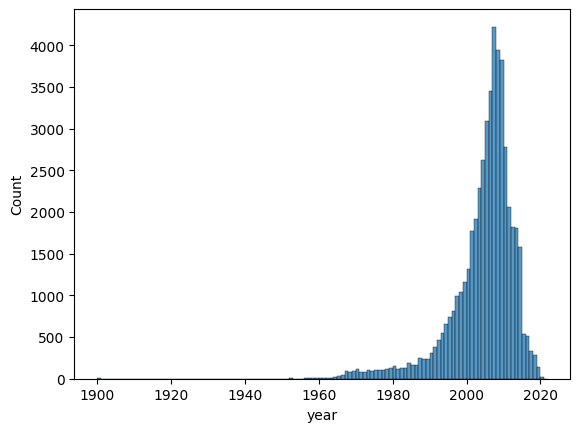

In [45]:
# number of songs per year in data
sns.histplot(df_songs,x="year",bins=df_songs["year"].max() - df_songs["year"].min(),stat="count")
plt.show()

In [46]:
# most songs from which year(top 5)
(
    df_songs
    .loc[:,"year"]
    .value_counts()
    .head(5)
    .sort_index()
)

,count
year,
2005,3085
2006,3453
2007,4221
2008,3947
2009,3827


**Keys**

Musical notes are assigned key values from **0 to 11**, representing all the chromatic notes in an octave. Here’s the mapping:  

| **Key Value** | **Note** |  
|---------------|-----------|  
| 0             | C         |  
| 1             | C# / Db   |  
| 2             | D         |  
| 3             | D# / Eb   |  
| 4             | E         |  
| 5             | F         |  
| 6             | F# / Gb   |  
| 7             | G         |  
| 8             | G# / Ab   |  
| 9             | A         |  
| 10            | A# / Bb   |  
| 11            | B         |  

### Notes Explained:  
- **Sharps (#):** Raise the note by a semitone (e.g., C → C#).  
- **Flats (b):** Lower the note by a semitone (e.g., D → Db).  

This cycle repeats across octaves!

**English vs Hindi Notes Comparison**

Here’s a table that maps **Key Value**, **English Notes**, and their corresponding **Hindi Music Notes (Swaras)**:  

| **Key Value** | **English Note** | **Hindi Music Note** |  
|---------------|------------------|-----------------------|  
| 0             | C                | Sa                   |  
| 1             | C# / Db          | Komal Re             |  
| 2             | D                | Re                   |  
| 3             | D# / Eb          | Komal Ga             |  
| 4             | E                | Ga                   |  
| 5             | F                | Ma                   |  
| 6             | F# / Gb          | Tivra Ma             |  
| 7             | G                | Pa                   |  
| 8             | G# / Ab          | Komal Dha            |  
| 9             | A                | Dha                  |  
| 10            | A# / Bb          | Komal Ni             |  
| 11            | B                | Ni                   |  

**Notes**:
- In **Hindi classical music**, "Komal" refers to flat (lowered) notes, and "Tivra" refers to sharp (raised) notes.
- The cycle repeats with "Sa" at the next octave!

-----

If a song has a key value of **2**, it means the song is composed in the **D major** or **D minor key**, depending on the **mode** (0 = minor, 1 = major).  

**Interpretation**:              
- **Key Value 2 (D):** The tonic note, or "home base," of the song is **D**. All other notes and chords in the song revolve around this note.
- **In Western Music:**  
  - **D Major:** Bright and uplifting.  
  - **D Minor:** Melancholic or introspective.
- **In Hindi Classical Music:** This corresponds to the "Re" swara (if D is treated as the Sa of the scale).

The overall mood or emotion of the song will depend on the mode and how the scale is used melodically and harmonically.

In [47]:
# unique values in the key column
(
    np.sort(df_songs
            .loc[:,"key"]
            .unique())
)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

<Axes: title={'center': 'Percentage of Songs wrt to Key'}, xlabel='Percentage', ylabel='key'>

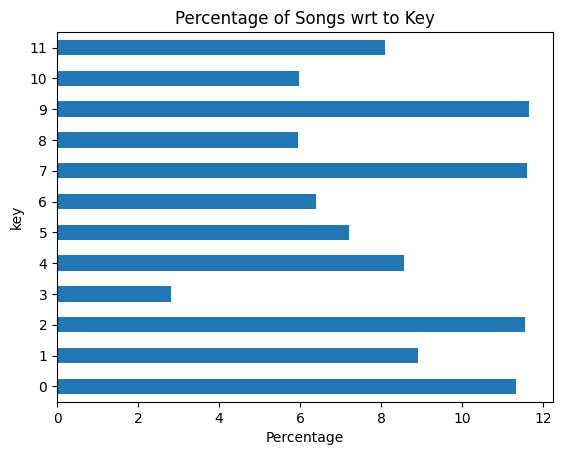

In [48]:
# percentage of songs wrt to key in the data
(
    df_songs['key']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
    .plot(kind='barh',title="Percentage of Songs wrt to Key",xlabel="Percentage")
)

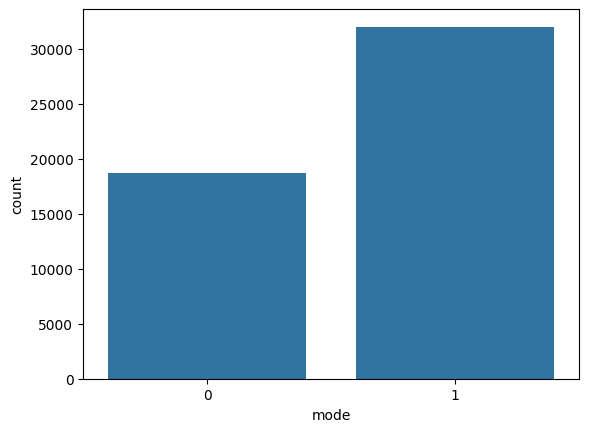

In [49]:
# countplot for mode
sns.countplot(df_songs,x="mode")
plt.show()

In [50]:
# unique values for time signature
(
    np.sort(df_songs
            .loc[:,"time_signature"]
            .unique())
)

array([0, 1, 3, 4, 5])

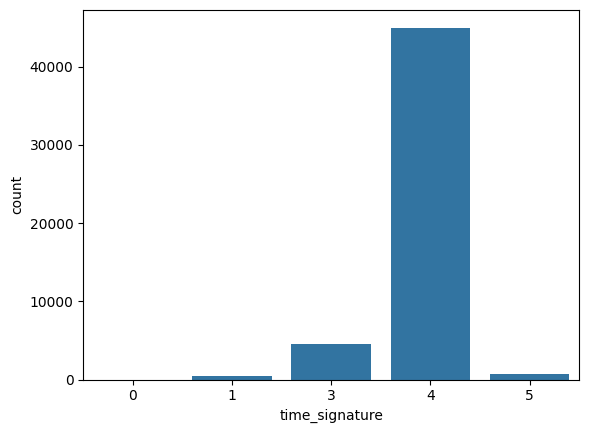

In [51]:
# countplot for time signature
sns.countplot(df_songs,x="time_signature")
plt.show()

In [52]:
(
    df_songs['time_signature']
    .value_counts(normalize=True)
    .mul(100)
)

,proportion
time_signature,
4,88.765442
3,8.880294
5,1.444528
1,0.890003
0,0.019734


In [53]:
# statistical summary of time duration
(
    df_songs
    .loc[:,["duration_ms"]]
    .assign(duration_minutes=df_songs["duration_ms"].div(1000).div(60))
    .drop(columns="duration_ms")
    .describe()
)

,duration_minutes
count,50674.000000
mean,4.185893
std,1.793154
min,0.023983
25%,3.212217
50%,3.915550
75%,4.803046
max,63.606217


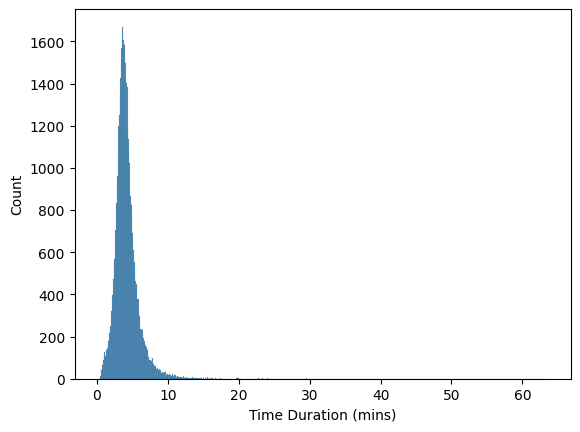

In [54]:
# time duration histogram
time_duration_mins = df_songs["duration_ms"].div(1000).div(60)
sns.histplot(time_duration_mins)
plt.xlabel("Time Duration (mins)")
plt.show()

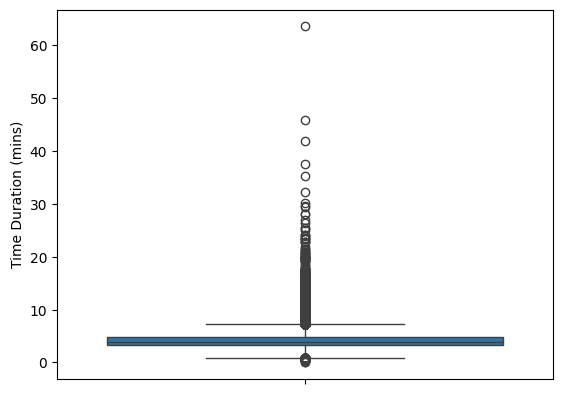

In [55]:
# time duration boxplot
sns.boxplot(time_duration_mins)
plt.ylabel("Time Duration (mins)")
plt.show()

In [56]:
# song that is longer than 60 mins
(
    df_songs
    .loc[time_duration_mins > 60]
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
25337,TRDAOJL128F932C383,Dopesmoker,Sleep,1vhvheW4R0KbK6Kr3NFplW,"psychedelic, doom_metal",NaN,2003,3816373,0.16,0.572,5,-6.949,1,0.0321,0.00367,0.745,0.0952,0.0932,96.926,4


### Continuous Columns

In [57]:
continuous_columns = df_songs.select_dtypes(include="float").columns
continuous_columns

Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo'],
      dtype='object')

**Danceability**
  
**What it means:** Measures how suitable a track is for dancing, based on tempo, rhythm stability, beat strength, and overall regularity.  
- **When value is small:** The song may feel less rhythmic or harder to dance to, like ballads or experimental music.  
- **When value is large:** The song is highly danceable, with a strong beat and rhythmic consistency, ideal for clubs or parties.  

---

**Energy**

**What it means:** Represents the intensity and activity of a song, considering factors like loudness, tempo, and instrumentation.  
- **When value is small:** The song feels mellow, calm, or laid-back, such as acoustic or chill tracks.  
- **When value is large:** The song feels loud, energetic, and lively, often found in rock or EDM genres.  

---

**Loudness**

**What it means:** The overall volume of the song in decibels (dB), averaged over the track.  
- **When value is small:** The song is quieter, suitable for soft or ambient styles.  
- **When value is large:** The song is louder and more powerful, typically associated with dynamic or energetic tracks.  

---

**Speechiness**

**What it means:** Measures the presence of spoken words in a track. A higher value indicates more speech-like content.  
- **When value is small:** The song is more musical, with fewer spoken or rap-like elements.  
- **When value is large:** The track has spoken word, podcast-style content, or heavy rap influence.  

---

**Acousticness**

**What it means:** Reflects how acoustic (non-electronic) the track is.  
- **When value is small:** The track is more electronic or synthetic in nature.  
- **When value is large:** The track is acoustic, featuring instruments like guitar, piano, or strings.  

---

**Instrumentalness**

**What it means:** Predicts the likelihood of a song having no vocals (purely instrumental).  
- **When value is small:** The track likely has vocals or lyrics.  
- **When value is large:** The track is primarily instrumental, like classical or ambient music.  

---

**Liveness**

**What it means:** Measures the presence of a live audience in the recording.  
- **When value is small:** The track sounds studio-produced without live ambiance.  
- **When value is large:** The track feels live, with audience sounds or a concert vibe.  

---

**Valence**

**What it means:** Indicates the positivity or happiness of a track's mood.  
- **When value is small:** The song feels sad, somber, or emotionally heavy.  
- **When value is large:** The song feels cheerful, uplifting, or happy.  

---

**Tempo**
  
**What it means:** The speed of the song in beats per minute (BPM).  
- **When value is small:** The song is slow-paced, such as ballads or downtempo tracks.  
- **When value is large:** The song is fast-paced, like dance or upbeat genres.  

In [58]:
def numerical_analysis(df,columns):
    for column in columns:
        print(f"Numerical Analysis for column {column}")
        print("Statistical Summary")
        print(df[column].describe())

        fig = plt.figure(figsize=(12,4))
        # hitogram for column
        plt.subplot(1,2,1)
        sns.histplot(df[column])
        plt.title(f"Histogram for {column}")
        # boxplot for column
        plt.subplot(1,2,2)
        sns.boxplot(df[column])
        plt.title(f"Boxplot for {column}")
        plt.show()

        print("#" * 120)
    print("*" * 120)
    print("Pairplot")
    sns.pairplot(df[columns])
    plt.show()

In [59]:
numerical_analysis(df_songs,continuous_columns)

Output hidden; open in https://colab.research.google.com to view.

# Users & Song Data

In [60]:
# load the dataset
df_users = pd.read_csv(users_data_path)
df_users.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [ ]:
# dataset info
df_users.info()

In [61]:
# check for duplicates
df_users.duplicated(subset=["track_id","user_id"]).sum()

np.int64(0)

**No duplicates in the data**

In [62]:
# check for missing values
df_users.isna().sum()

,0
track_id,0
user_id,0
playcount,0


In [63]:
# unqiue users in the data
(
    df_users
    .loc[:,"user_id"]
    .nunique()
)

962037

In [64]:
# unique songs in the data
(
    df_users
    .loc[:,"track_id"]
    .nunique()
)

30459

In [65]:
# top 10 most played songs in user data
(
    df_users
    .loc[:,"track_id"]
    .value_counts()
    .head(10)
)

,count
track_id,
TRONYHY128F92C9D11,80656
TRUFTBY128F93450B8,39529
TRXWAZC128F9314B3E,30873
TRCPXID128F92D5D3C,30057
TRGCHLH12903CB7352,29708
TROMKCG128F9320C09,28735
TRPFYYL128F92F7144,28412
TRPGPDK12903CCC651,27276
TRWAQOC12903CB84CA,27222


In [66]:
top_10_songs = (
    df_users
    .loc[:,"track_id"]
    .value_counts()
    .head(10)
)
top_10_songs

,count
track_id,
TRONYHY128F92C9D11,80656
TRUFTBY128F93450B8,39529
TRXWAZC128F9314B3E,30873
TRCPXID128F92D5D3C,30057
TRGCHLH12903CB7352,29708
TROMKCG128F9320C09,28735
TRPFYYL128F92F7144,28412
TRPGPDK12903CCC651,27276
TRWAQOC12903CB84CA,27222


In [67]:
(
    df_songs
    .loc[df_songs["track_id"].isin(top_10_songs.index.tolist()),:]
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
44,TRAALAH128E078234A,Bitter Sweet Symphony,The Verve,0jLnevC3Vn34qVWrAa4X6x,"rock, alternative, indie, pop, alternative_roc...",NaN,1999,358333,0.383,0.907,9,-5.409,1,0.0405,0.031300,0.000000,0.3470,0.514,171.052,4
59,TRPFYYL128F92F7144,Float On,Modest Mouse,1Urf1M52P3R6NYdAOJizoW,"rock, alternative, indie, alternative_rock, in...",Rock,2004,208466,0.646,0.893,6,-4.799,1,0.0301,0.015100,0.000004,0.0892,0.559,100.951,4
323,TRONYHY128F92C9D11,Revelry,Kings of Leon,039Q3UlFQ6kavVIZHpO4mL,"rock, alternative, indie, alternative_rock, in...",Rock,2008,201733,0.437,0.748,4,-6.593,1,0.0689,0.196000,0.000328,0.1580,0.383,149.834,4
1876,TRXWAZC128F9314B3E,Heartbreak Warfare,John Mayer,0naTARZScsZOtx3nlhlq0Y,"rock, alternative, indie, pop, singer_songwrit...",Rock,2010,263280,0.626,0.572,2,-7.989,1,0.0228,0.197000,0.000497,0.2720,0.297,97.081,4
2107,TRUFTBY128F93450B8,Alejandro,Lady Gaga,0CXHrBetrvDx4PwBar1ZWj,"electronic, pop, female_vocalists, dance",Pop,2010,274800,0.626,0.800,11,-6.777,0,0.0435,0.000582,0.001140,0.3740,0.353,98.995,4
2742,TRCPXID128F92D5D3C,Halo,Depeche Mode,0Ti7ZxvgWq74Ls56vYP3Ov,"electronic, pop, 80s, british, 90s, new_wave, ...",NaN,1990,270160,0.672,0.508,3,-12.620,0,0.0310,0.052800,0.067100,0.0801,0.741,112.184,4
3168,TRWAQOC12903CB84CA,Sexy Bitch,David Guetta,01N6xy2PX9fKVfrA2YOkYd,"electronic, dance, house",NaN,2009,193800,0.810,0.595,11,-5.812,0,0.0579,0.067300,0.000764,0.1190,0.813,130.018,4
19724,TROMKCG128F9320C09,Uprising,Sabaton,09tHVoXbJNZUotndn8pfJr,"metal, heavy_metal, power_metal",NaN,2010,295640,0.527,0.866,6,-3.763,0,0.0346,0.009910,0.000052,0.1290,0.428,87.986,4
22071,TRPGPDK12903CCC651,Bring Me To Life,Katherine Jenkins,0rJ8HF2zsxsWMzirj3YFQR,"classical, cover, new_age",Rock,2012,226093,0.429,0.563,4,-8.006,0,0.0300,0.881000,0.000097,0.0760,0.298,95.989,4
23220,TRGCHLH12903CB7352,Party In The U.S.A.,The Barden Bellas,0bz2Uy1KE7bNGsGQU9pZrU,"soundtrack, cover",Pop,2012,63080,0.531,0.360,10,-8.575,0,0.1080,0.822000,0.000000,0.1780,0.701,97.200,4


In [68]:
# most playcounts for songs
top_10_played_songs = (
    df_users.groupby("track_id")['playcount']
    .agg("sum")
    .sort_values(ascending=False)
    .head(10)
)
top_10_played_songs

,playcount
track_id,
TRONYHY128F92C9D11,527893
TRUFTBY128F93450B8,111615
TRZNAHL128F9327D5A,111596
TRCPXID128F92D5D3C,91461
TRPGPDK12903CCC651,91448
TRXWAZC128F9314B3E,87745
TROMKCG128F9320C09,87050
TRPFYYL128F92F7144,85079
TRGCHLH12903CB7352,78443


In [69]:
(
    df_songs
    .loc[df_songs["track_id"].isin(top_10_played_songs.index.tolist()),:]
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
44,TRAALAH128E078234A,Bitter Sweet Symphony,The Verve,0jLnevC3Vn34qVWrAa4X6x,"rock, alternative, indie, pop, alternative_roc...",NaN,1999,358333,0.383,0.907,9,-5.409,1,0.0405,0.031300,0.000000,0.3470,0.5140,171.052,4
59,TRPFYYL128F92F7144,Float On,Modest Mouse,1Urf1M52P3R6NYdAOJizoW,"rock, alternative, indie, alternative_rock, in...",Rock,2004,208466,0.646,0.893,6,-4.799,1,0.0301,0.015100,0.000004,0.0892,0.5590,100.951,4
323,TRONYHY128F92C9D11,Revelry,Kings of Leon,039Q3UlFQ6kavVIZHpO4mL,"rock, alternative, indie, alternative_rock, in...",Rock,2008,201733,0.437,0.748,4,-6.593,1,0.0689,0.196000,0.000328,0.1580,0.3830,149.834,4
1876,TRXWAZC128F9314B3E,Heartbreak Warfare,John Mayer,0naTARZScsZOtx3nlhlq0Y,"rock, alternative, indie, pop, singer_songwrit...",Rock,2010,263280,0.626,0.572,2,-7.989,1,0.0228,0.197000,0.000497,0.2720,0.2970,97.081,4
2107,TRUFTBY128F93450B8,Alejandro,Lady Gaga,0CXHrBetrvDx4PwBar1ZWj,"electronic, pop, female_vocalists, dance",Pop,2010,274800,0.626,0.800,11,-6.777,0,0.0435,0.000582,0.001140,0.3740,0.3530,98.995,4
2742,TRCPXID128F92D5D3C,Halo,Depeche Mode,0Ti7ZxvgWq74Ls56vYP3Ov,"electronic, pop, 80s, british, 90s, new_wave, ...",NaN,1990,270160,0.672,0.508,3,-12.620,0,0.0310,0.052800,0.067100,0.0801,0.7410,112.184,4
19724,TROMKCG128F9320C09,Uprising,Sabaton,09tHVoXbJNZUotndn8pfJr,"metal, heavy_metal, power_metal",NaN,2010,295640,0.527,0.866,6,-3.763,0,0.0346,0.009910,0.000052,0.1290,0.4280,87.986,4
22071,TRPGPDK12903CCC651,Bring Me To Life,Katherine Jenkins,0rJ8HF2zsxsWMzirj3YFQR,"classical, cover, new_age",Rock,2012,226093,0.429,0.563,4,-8.006,0,0.0300,0.881000,0.000097,0.0760,0.2980,95.989,4
23220,TRGCHLH12903CB7352,Party In The U.S.A.,The Barden Bellas,0bz2Uy1KE7bNGsGQU9pZrU,"soundtrack, cover",Pop,2012,63080,0.531,0.360,10,-8.575,0,0.1080,0.822000,0.000000,0.1780,0.7010,97.200,4
25264,TRZNAHL128F9327D5A,Gears,Miss May I,3YC9z1sMjAxn5noHpBLBXd,"metalcore, post_hardcore, screamo",NaN,2010,241466,0.470,0.975,5,-4.479,1,0.1360,0.000027,0.000187,0.1430,0.0796,123.022,4


In [70]:
pd.concat([top_10_songs,top_10_played_songs],axis=1)

,count,playcount
track_id,,
TRONYHY128F92C9D11,80656.0,527893.0
TRUFTBY128F93450B8,39529.0,111615.0
TRXWAZC128F9314B3E,30873.0,87745.0
TRCPXID128F92D5D3C,30057.0,91461.0
TRGCHLH12903CB7352,29708.0,78443.0
TROMKCG128F9320C09,28735.0,87050.0
TRPFYYL128F92F7144,28412.0,85079.0
TRPGPDK12903CCC651,27276.0,91448.0
TRWAQOC12903CB84CA,27222.0,NaN


In [71]:
# most diverse users
# top 10
most_diverse_users = (
                        df_users.groupby("user_id")['track_id']
                        .agg("count")
                        .sort_values(ascending=False)
                        .head(10)
                    )
most_diverse_users

,track_id
user_id,
ec6dfcf19485cb011e0b22637075037aae34cf26,784
4e11f45d732f4861772b2906f81a7d384552ad12,384
726da71c2c2ea119119a7957517fccd028d1be76,376
113255a012b2affeab62607563d03fbdf31b08e7,367
7adec7f006cb09482d36609d205293d8b61f030e,366
fef771ab021c200187a419f5e55311390f850a50,363
8cb51abc6bf8ea29341cb070fe1e1af5e4c3ffcc,362
b4c94d72b15d3c311c10045a58b31f95d9d12785,357
96f7b4f800cafef33eae71a6bc44f7139f63cd7a,356


In [72]:
# most playcounts for users
# top 10
most_active_users = (
                        df_users.groupby("user_id")['playcount']
                        .agg("sum")
                        .sort_values(ascending=False)
                        .head(10)
                    )
most_active_users

,playcount
user_id,
1854daf178674bbac9a8ed3d481f95b76676b414,2953
944cdf52364f45b0edd1c972b5a73d3a86b09c6a,2046
6a8a142084a4818c0dcac48bdfb3c39deacf5168,1942
93158e3983ffc8945e25c793d93d6b67d46cae9d,1845
f0b5c784daaa3c7d50acbb3723c7dd649db2b231,1841
6a58f480d522814c087fd3f8c77b3f32bb161f9d,1783
49127655d27dabab3f469bcdd996330fe4f3e210,1743
3fa44653315697f42410a30cb766a4eb102080bb,1639
839223f11c98e0c8017e8ecd6fc7b8706658c966,1608


In [73]:
pd.concat([most_diverse_users,most_active_users],axis=1)

,track_id,playcount
user_id,,
ec6dfcf19485cb011e0b22637075037aae34cf26,784.0,NaN
4e11f45d732f4861772b2906f81a7d384552ad12,384.0,NaN
726da71c2c2ea119119a7957517fccd028d1be76,376.0,NaN
113255a012b2affeab62607563d03fbdf31b08e7,367.0,NaN
7adec7f006cb09482d36609d205293d8b61f030e,366.0,NaN
fef771ab021c200187a419f5e55311390f850a50,363.0,NaN
8cb51abc6bf8ea29341cb070fe1e1af5e4c3ffcc,362.0,NaN
b4c94d72b15d3c311c10045a58b31f95d9d12785,357.0,NaN
96f7b4f800cafef33eae71a6bc44f7139f63cd7a,356.0,NaN


In [74]:
!git config --global user.email "apoorva.akb@gmail.com"
!git config --global user.name "Apoo3va"

In [77]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')

!git clone https://{token}@github.com/Apoo3va/hybrid-recommender-system.git

Cloning into 'hybrid-recommender-system'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.


In [78]:
!ls hybrid-recommender-system

LICENSE  README.md


In [83]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [84]:
!ls "/content/drive/MyDrive/Colab Notebooks"

'Copy of session2-operators-if-else-loops.ipynb'
'data scraping.ipynb'
 driver_behavior_improved.ipynb
 EDA.ipynb
 IITJ-27June.ipynb
 main3.ipynb
 motion_classification.ipynb
'Python Functions Practice Set - 3'
'Python Programming Assignment 4.ipynb'
'Telegram bot.ipynb'
 Untitled0.ipynb


In [87]:
import shutil
shutil.copy('/content/drive/MyDrive/Colab Notebooks/EDA.ipynb', '/content/hybrid-recommender-system/EDA.ipynb')

'/content/hybrid-recommender-system/EDA.ipynb'

In [88]:
%cd /content/hybrid-recommender-system

/content/hybrid-recommender-system


In [89]:
!ls

EDA.ipynb  LICENSE  README.md


In [90]:
!git add EDA.ipynb
!git commit -m "Add EDA notebook from Colab"
!git push

[main 5dc2a67] Add EDA notebook from Colab
 1 file changed, 1 insertion(+)
 create mode 100644 EDA.ipynb
remote: Permission to Apoo3va/hybrid-recommender-system.git denied to Apoo3va.
fatal: unable to access 'https://github.com/Apoo3va/hybrid-recommender-system.git/': The requested URL returned error: 403
